In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.59G/1.59G [01:17<00:00, 22.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1):
['dataset']


In [ ]:
import os

# Explore the structure inside the drone-vs-bird dataset
# The previous cell showed the contents of 'path' is ['dataset']
drone_dataset_path = os.path.join(path, 'dataset')

if os.path.exists(drone_dataset_path):
    print(f"Subdirectories in drone dataset: {os.listdir(drone_dataset_path)}")
else:
    print(f"Directory {drone_dataset_path} does not exist. Please check the file structure.")

Subdirectories in drone dataset: ['bird', 'drone']


Found 4104 images. Displaying 6 sample images:


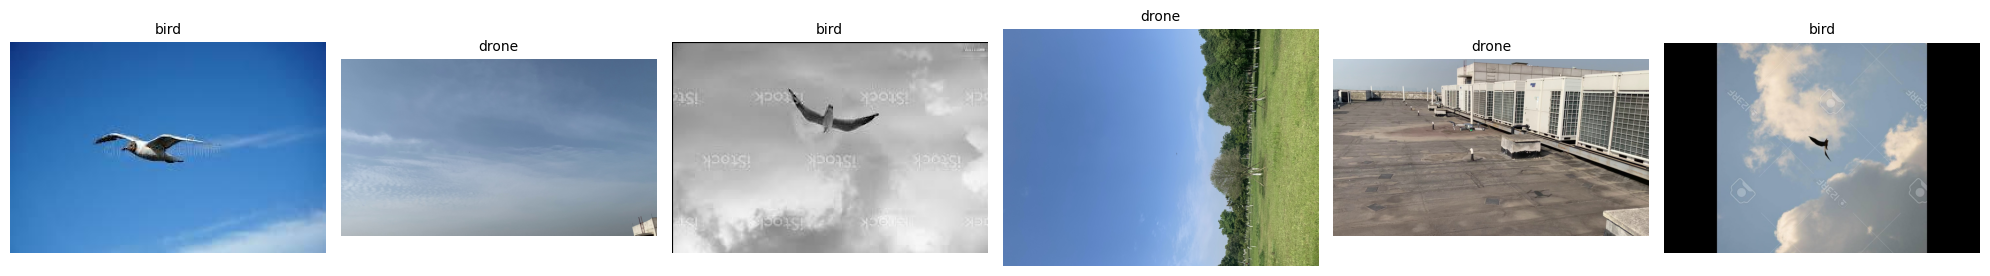

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1: axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the path defined in cell 2 for the drone dataset
drone_dataset_path = os.path.join(path, 'dataset')
display_sample_images(drone_dataset_path)

In [ ]:
!pip install split-folders

In [ ]:
import os
# Ensure the library is available in the current environment
!pip install split-folders

import splitfolders

# Input folder from the drone-vs-bird dataset
input_folder = os.path.join(path, 'dataset')
output_folder = '/content/drone_bird_split'

# Create output directory if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Split data: train=0.8, val=0.2
if os.path.exists(input_folder):
    print(f"Splitting files from {input_folder} to {output_folder}...")
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)
    print(f"Data successfully split into: {output_folder}")
    print(f"Subdirectories created: {os.listdir(output_folder)}")
else:
    print(f"Error: Input directory {input_folder} not found.")

Splitting files from /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1/dataset to /content/drone_bird_split...


Copying files: 4106 files [00:10, 387.76 files/s]

Data successfully split into: /content/drone_bird_split
Subdirectories created: ['val', 'train']


In [ ]:
def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_dir = os.path.join(output_folder, 'train')
val_dir = os.path.join(output_folder, 'val')

train_count = count_files(train_dir)
val_count = count_files(val_dir)
total = train_count + val_count

print(f"Dataset Split Statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Val (Test) Set: {val_count} images ({val_count/total*100:.1f}%)")
print(f"- Total: {total} images")

Dataset Split Statistics:
- Train Set: 3284 images (80.0%)
- Val (Test) Set: 822 images (20.0%)
- Total: 4106 images


In [ ]:
import torch

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

Using device: cuda
Tesla T4
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import time

# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(output_folder, x), data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# Build ResNet18 model
model = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    for phase in ['train', 'val']:
        if phase == 'train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 221MB/s]


Epoch 1/10
train Loss: 0.3583 Acc: 0.8636
val Loss: 0.2840 Acc: 0.8942
Epoch 2/10
train Loss: 0.2498 Acc: 0.9053
val Loss: 0.2830 Acc: 0.8674
Epoch 3/10
train Loss: 0.2353 Acc: 0.9108
val Loss: 0.2357 Acc: 0.9100
Epoch 4/10
train Loss: 0.1942 Acc: 0.9208
val Loss: 0.1452 Acc: 0.9574
Epoch 5/10
train Loss: 0.2054 Acc: 0.9260
val Loss: 0.2511 Acc: 0.8893
Epoch 6/10
train Loss: 0.1644 Acc: 0.9364
val Loss: 0.0706 Acc: 0.9745
Epoch 7/10
train Loss: 0.1875 Acc: 0.9327
val Loss: 0.1866 Acc: 0.9477
Epoch 8/10
train Loss: 0.1638 Acc: 0.9409
val Loss: 0.1117 Acc: 0.9550
Epoch 9/10
train Loss: 0.1471 Acc: 0.9449
val Loss: 0.1422 Acc: 0.9416
Epoch 10/10
train Loss: 0.1544 Acc: 0.9412
val Loss: 0.1618 Acc: 0.9489


In [ ]:
print("--- Training Summary ---")
final_train_acc = history['train_acc'][-1]
final_val_acc = history['val_acc'][-1]
best_val_acc = max(history['val_acc'])

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Classes detected: {class_names}")

--- Training Summary ---
Final Training Accuracy: 0.9412
Final Validation Accuracy: 0.9489
Best Validation Accuracy: 0.9745
Classes detected: ['bird', 'drone']


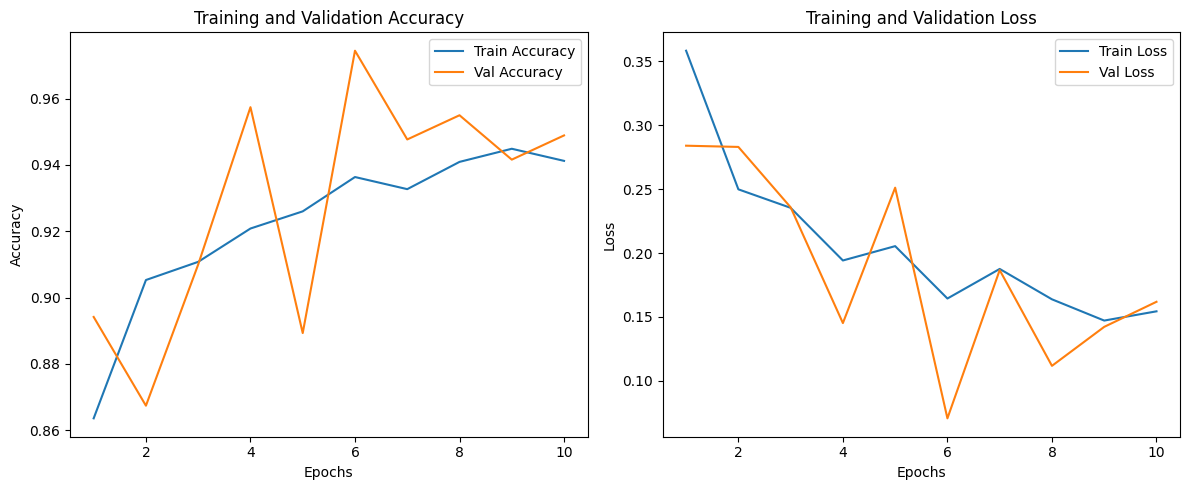

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_acc'], label='Train Accuracy')
plt.plot(epochs_range, history['val_acc'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Train Loss')
plt.plot(epochs_range, history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()